In [1]:
import snapatac2 as snap
import os
import sys
import scanpy as sc
import pandas as pd 
import anndata as ad
import scvi

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
%%time
data = snap.pp.import_fragments(
    "/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/cryo/outs/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,
    sorted_by_barcode=False,
)
data

CPU times: user 2min 1s, sys: 4.87 s, total: 2min 6s
Wall time: 59.1 s


AnnData object with n_obs × n_vars = 4314 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [92]:
data= ad.read_h5ad("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_cryo_ctx/cryo_ctx_annotated.h5ad")

2026-10-05 12:52:13 - INFO - Computing fragment size distribution...


2026-10-05 12:52:17 - INFO - Chromium init'ed with kwargs {}
2026-10-05 12:52:17 - INFO - Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-10-05 12:52:17 - INFO - Temp directory created: /tmp/tmpire_3w2j.
2026-10-05 12:52:17 - INFO - Opening browser.
2026-10-05 12:52:17 - INFO - Temp directory created: /tmp/tmph8gsu773.
2026-10-05 12:52:17 - INFO - Temporary directory at: /tmp/tmph8gsu773
2026-10-05 12:52:18 - INFO - Conforming 1 to file:///tmp/tmpire_3w2j/index.html
2026-10-05 12:52:18 - INFO - Waiting on all navigates
2026-10-05 12:52:20 - INFO - All navigates done, putting them all in queue.
2026-10-05 12:52:20 - INFO - Getting tab from queue (has 1)
2026-10-05 12:52:20 - INFO - Got F01E
2026-10-05 12:52:20 - INFO - Processing fig.png
2026-10-05 12:52:20 - INFO - Sending big command for fig.png.
2026-10-05 12:52:20 - INFO - Sent big command for fig.png.
2026-10-05 12:52:20 - INFO - 

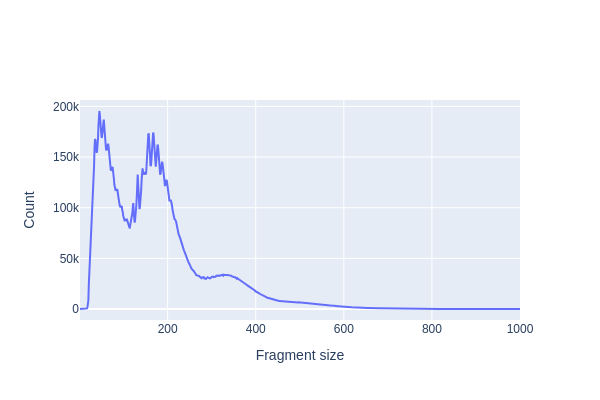

In [3]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''



snap.pl.frag_size_distr(data, interactive=False)

In [5]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

In [100]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

2026-10-06 12:11:56 - INFO - Chromium init'ed with kwargs {}
2026-10-06 12:11:56 - INFO - Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-10-06 12:11:56 - INFO - Temp directory created: /tmp/tmpodrd7urs.
2026-10-06 12:11:56 - INFO - Opening browser.
2026-10-06 12:11:56 - INFO - Temp directory created: /tmp/tmp0bunmdj0.
2026-10-06 12:11:56 - INFO - Temporary directory at: /tmp/tmp0bunmdj0


2026-10-06 12:11:57 - INFO - Conforming 1 to file:///tmp/tmpodrd7urs/index.html
2026-10-06 12:11:57 - INFO - Waiting on all navigates
2026-10-06 12:11:59 - INFO - All navigates done, putting them all in queue.
2026-10-06 12:11:59 - INFO - Getting tab from queue (has 1)
2026-10-06 12:11:59 - INFO - Got 06E2
2026-10-06 12:11:59 - INFO - Processing fig.png
2026-10-06 12:11:59 - INFO - Sending big command for fig.png.
2026-10-06 12:11:59 - INFO - Sent big command for fig.png.
2026-10-06 12:11:59 - INFO - Reloading tab 06E2 before return.
2026-10-06 12:11:59 - INFO - Putting tab 06E2 back (queue size: 0).
2026-10-06 12:11:59 - INFO - Waiting for all cleanups to finish.
2026-10-06 12:11:59 - INFO - Exiting Kaleido
2026-10-06 12:11:59 - INFO - Closing browser.
2026-10-06 12:11:59 - INFO - Closing browser.
2026-10-06 12:11:59 - INFO - TemporaryDirectory.cleanup() worked.
2026-10-06 12:11:59 - INFO - shutil.rmtree worked.
2026-10-06 12:11:59 - INFO - Cancelling tasks.
2026-10-06 12:11:59 - INFO

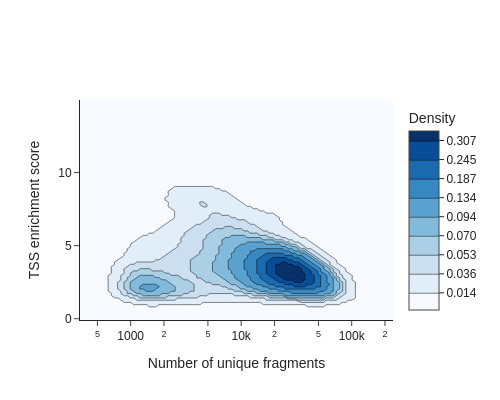

In [94]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=False)


##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

In [101]:
## Oprion - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=4000, min_tsse=1.5, max_counts=100000)
data

AnnData object with n_obs × n_vars = 864 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'doublet_rate', 'frac_overlap_TSS', 'library_tsse', 'reference_sequences', 'scrublet_sim_doublet_score', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'

In [102]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [103]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=150000)

2026-10-06 12:16:33 - INFO - Selected 150000 features.


In [104]:
%%time
snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2026-10-06 12:16:33 - INFO - Simulating doublets...
2026-10-06 12:16:33 - INFO - Spectral embedding ...
2026-10-06 12:16:34 - INFO - TemporaryDirectory.cleanup() worked.
2026-10-06 12:16:34 - INFO - shutil.rmtree worked.
2026-10-06 12:16:52 - INFO - Calculating doublet scores...
2026-10-06 12:16:53 - INFO - Detected doublet rate = 0.463%


CPU times: user 34.4 s, sys: 1.13 s, total: 35.5 s
Wall time: 24.4 s


AnnData object with n_obs × n_vars = 860 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'doublet_rate', 'frac_overlap_TSS', 'library_tsse', 'reference_sequences', 'scrublet_sim_doublet_score', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'

/home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-10-06 12:17:04 - INFO - Chromium init'ed with kwargs {}
2026-10-06 12:17:04 - INFO - Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-10-06 12:17:04 - INFO - Temp directory created: /tmp/tmpm2eoo_au.
2026-10-06 12:17:04 - INFO - Opening browser.
2026-10-06 12:17:04 - INFO - Temp directory created: /tmp/tmpnvm2lu5t.
2026-10-06 12:17:04 - INFO - Temporary directory at: /tmp/tmpnvm2lu5t
2026-10-06 12:17:05 - INFO - Conforming 1 to file:///tmp/tmpm2eoo_au/index.html
2026-10-06 12:17:05 - INFO - Waiting on all navigates
2026-10-06 12:17:07 - INFO - All navigates done, putting them all in queue.
2026-10-06 12:17:07 - INFO - Getting tab from queue (has 1)
2026-10-06 12:17:07 - INFO - Got E3CD

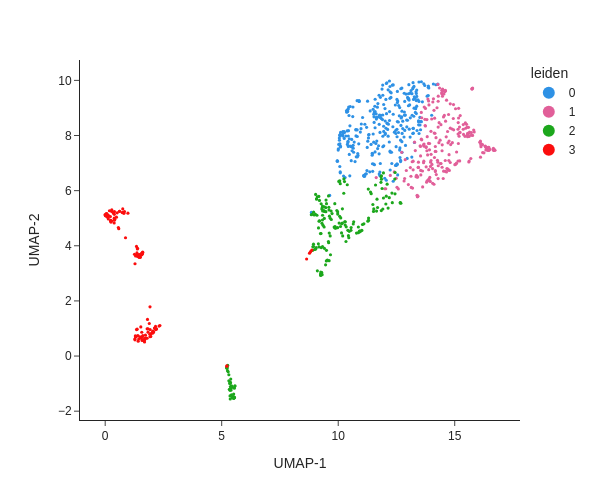

In [105]:
snap.tl.spectral(data)
snap.tl.umap(data) 
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.5)

snap.pl.umap(data, color='leiden', interactive=False, height=500)

2026-10-05 17:04:24 - INFO - TemporaryDirectory.cleanup() worked.
2026-10-05 17:04:24 - INFO - shutil.rmtree worked.


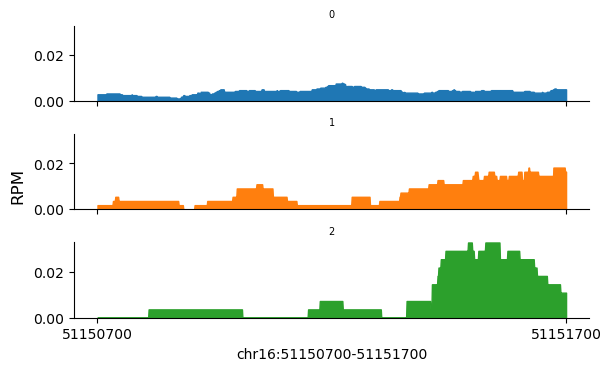

In [103]:
#Visualise accesibility of promoter regions of marker genes
snap.pl.coverage(data, region='chr16:51150700-51151700', groupby='leiden')


In [68]:
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 1082 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'cell_type'

In [69]:
### The cell by gene activity matrix is sparse
## The MAGIC algorithm performs imputation and data smoothing
## Then scanpy does subsequent steps 
## First perform gene filtering, normalisation and transformation and then call MAGIC
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
# Skip MAGIC imputation - the analysis will work fine without it
sc.external.pp.magic(gene_matrix, solver="approximate")

# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

2026-10-06 11:34:41 - INFO - TemporaryDirectory.cleanup() worked.
2026-10-06 11:34:41 - INFO - shutil.rmtree worked.


... storing 'leiden' as categorical


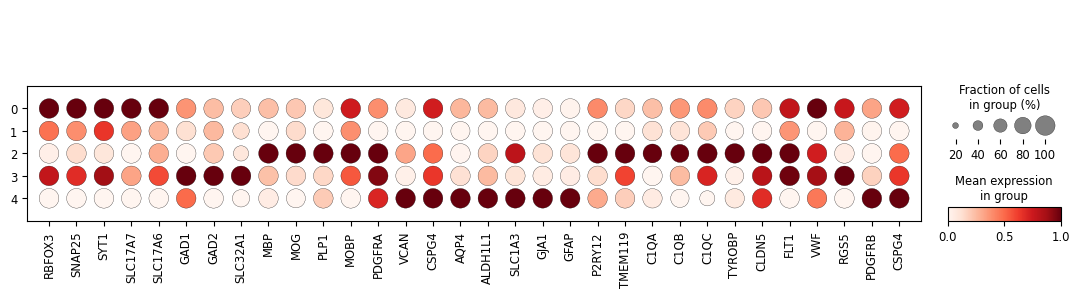

In [70]:
markers = [
    # Neurons
    "RBFOX3", "SNAP25", "SYT1",
    "SLC17A7", "SLC17A6",        # excitatory
    "GAD1", "GAD2", "SLC32A1",   # inhibitory

    # Oligodendrocytes / OPCs
    "MBP", "MOG", "PLP1", "MOBP",
    "PDGFRA", "VCAN", "CSPG4",

    # Astrocytes
    "AQP4", "ALDH1L1", "SLC1A3", "GJA1", "GFAP",

    # Microglia
    "P2RY12", "TMEM119", "C1QA", "C1QB", "C1QC", "TYROBP",

    # Vasculature
    "CLDN5", "FLT1", "VWF",      # endothelial
    "RGS5", "PDGFRB", "CSPG4"    # pericyte / mural
]

markers = [g for g in markers if g in gene_matrix.var_names]

sc.pl.dotplot(
    gene_matrix,
    var_names=markers,
    groupby="leiden",
    use_raw=False,
    standard_scale="var"
)

2026-10-05 17:11:31 - INFO - Chromium init'ed with kwargs {}
2026-10-05 17:11:31 - INFO - Found chromium path: /home/elliot/miniconda3/envs/atac_env190516/lib/python3.10/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
2026-10-05 17:11:31 - INFO - Temp directory created: /tmp/tmpnvav4e_r.
2026-10-05 17:11:31 - INFO - Opening browser.
2026-10-05 17:11:31 - INFO - Temp directory created: /tmp/tmplxzjh3__.
2026-10-05 17:11:31 - INFO - Temporary directory at: /tmp/tmplxzjh3__
2026-10-05 17:11:32 - INFO - Conforming 1 to file:///tmp/tmpnvav4e_r/index.html
2026-10-05 17:11:32 - INFO - Waiting on all navigates
2026-10-05 17:11:34 - INFO - All navigates done, putting them all in queue.
2026-10-05 17:11:34 - INFO - Getting tab from queue (has 1)
2026-10-05 17:11:34 - INFO - Got 3BB0
2026-10-05 17:11:34 - INFO - Processing fig.png
2026-10-05 17:11:34 - INFO - Sending big command for fig.png.
2026-10-05 17:11:35 - INFO - Sent big command for fig.png.
2026-10-05 17:11:35 - INFO - 

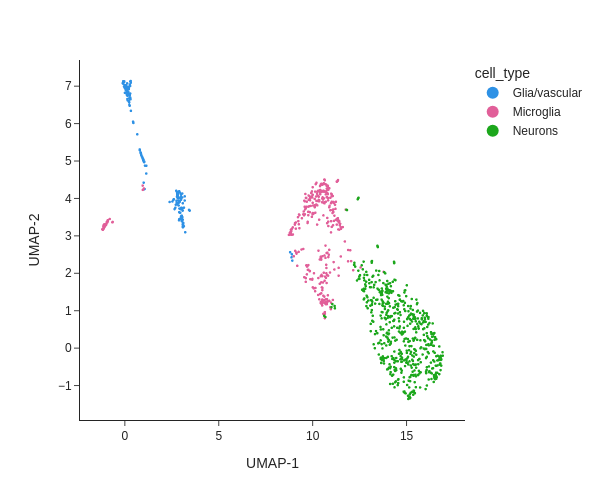

In [111]:
snap.pl.umap(
    data,
    color="cell_type",
    interactive=False,
    height=500
)

In [ ]:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!    mtDNA VARIANT CALLING !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [106]:
import sys
sys.path.insert(0, '/mnt/claw-raid/elliot/P002_mtscATAC-seq/scripts/Py_mTCall_tools/Py_mTCall_tools')
import variant_calling_fast as vc
mgatk = vc.process_variants_fast("/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_cryo_ctx/Elliot_mgatk/final", data, verbose=True, coverage_threshold=10, min_strand_count=2)



=== Fast Variant Calling Pipeline ===


You'll find variant names in adata.uns['variant_names']

Find coverage PER cell in adata.obsm['coverage_per_cell']

Variant summmary stats similar to Signac are in adata.uns['variant_summary']

Variant matrices are in adata.obsm["variant_vaf"]


=== IMPORTANT NOTE ===

Remember that variant VAFs are only included if they pass the min_strand_count filter

AND the coverage threshold if specified!





2026-10-06 12:18:02 - INFO - TemporaryDirectory.cleanup() worked.
2026-10-06 12:18:02 - INFO - shutil.rmtree worked.


Loaded counts data: (115422, 1277)
Loaded coverage data: (18422104, 3)
Identifying variants (memory-optimized chunked method)...
Processing all 82239 variant observations (no artificial limits)
Integrating with AnnData...
=== Pipeline Complete ===
Processed 261 variants in 752 matching cells


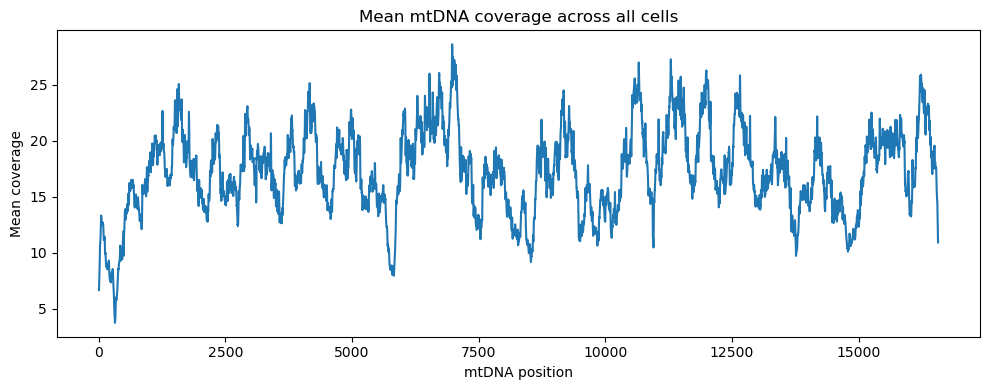

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

file = "/mnt/claw-raid/elliot/P002_mtscATAC-seq/data/processed/atac_cryo_ctx/Elliot_mgatk/final/mgatk.coverage.txt"

cov = pd.read_csv(
    file,
    sep=",",
    header=None,
    names=["position", "cell", "coverage"]
)

profile = (
    cov.groupby("position")["coverage"]
       .mean()
       .sort_index()
       .rolling(5, center=True)
       .mean()
)

plt.figure(figsize=(10, 4))
plt.plot(profile.index, profile.values)
plt.xlabel("mtDNA position")
plt.ylabel("Mean coverage")
plt.title("Mean mtDNA coverage across all cells")
plt.tight_layout()
plt.show()


strict: 2 variants
 variant  n_cells_conf_detected  mean_coverage  strand_concordance  vaf_overall
A-9275-C                     12      19.152276            0.815220     0.004877
A-8836-G                     10      13.449765            0.867284     0.005427


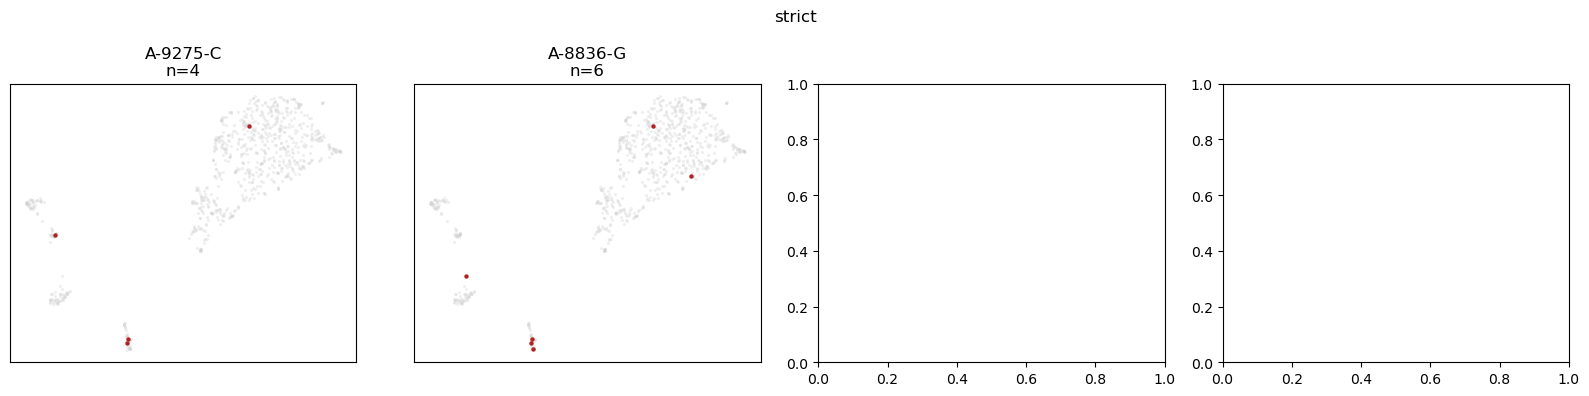


moderate: 6 variants
  variant  n_cells_conf_detected  mean_coverage  strand_concordance  vaf_overall
 C-8844-T                      9      13.700157            0.824880     0.005844
C-16148-T                      8      17.419152            0.855184     0.004506
 A-9275-C                     12      19.152276            0.815220     0.004877
 A-8836-G                     10      13.449765            0.867284     0.005427
   C-64-T                      7      10.679749            0.763542     0.003675
G-16390-A                      7      19.883830            0.876984     0.001934


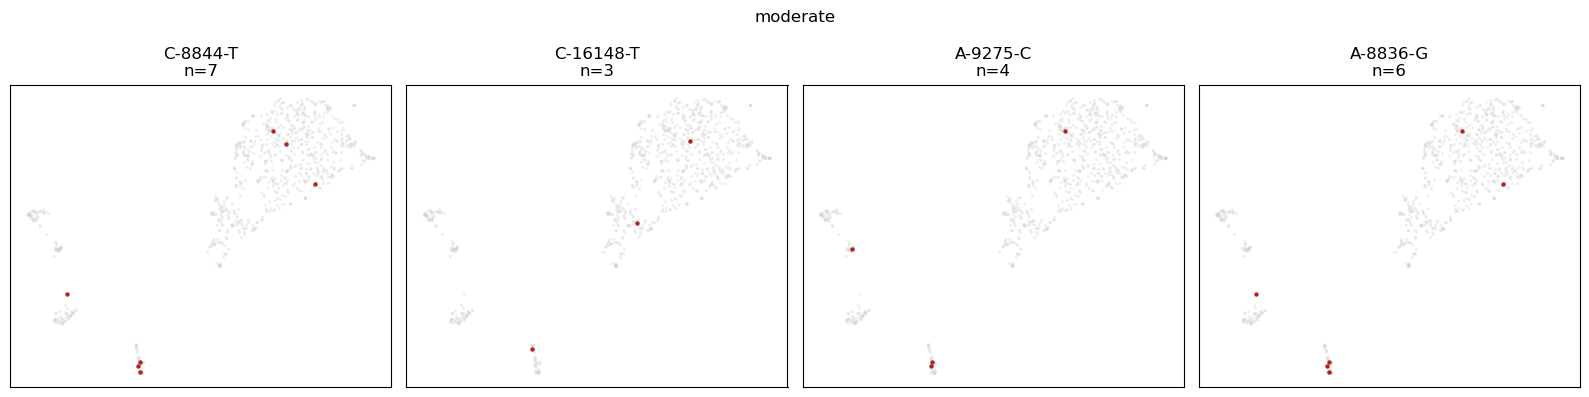


permissive: 9 variants
  variant  n_cells_conf_detected  mean_coverage  strand_concordance  vaf_overall
  A-189-G                     24       6.917582            0.741503     0.028027
  A-238-G                     14       5.590267            0.754054     0.014322
 C-8844-T                      9      13.700157            0.824880     0.005844
C-16148-T                      8      17.419152            0.855184     0.004506
 A-9275-C                     12      19.152276            0.815220     0.004877
 A-8836-G                     10      13.449765            0.867284     0.005427
   C-64-T                      7      10.679749            0.763542     0.003675
 A-9567-G                      6      10.768446            0.670238     0.003790
G-16390-A                      7      19.883830            0.876984     0.001934


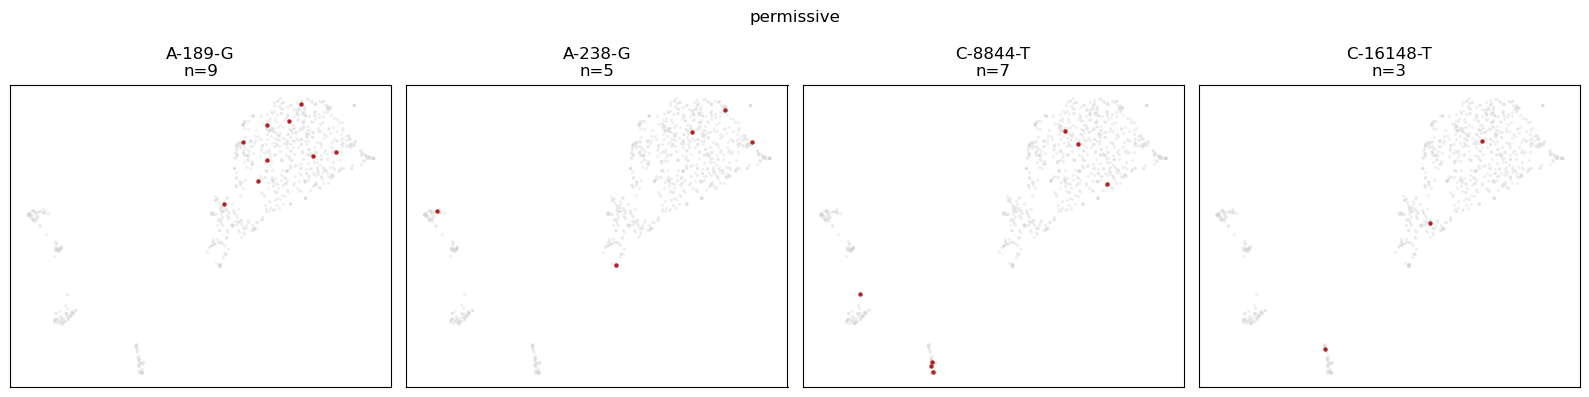

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

summary = pd.DataFrame(mgatk.uns["variant_summary"]).copy()
summary["variant"] = np.asarray(
    mgatk.uns["variant_names"]
).astype(str)

vaf = mgatk.obsm["variant_vaf"]
if sparse.issparse(vaf):
    vaf = vaf.toarray()

vaf = np.asarray(vaf)
umap = np.asarray(mgatk.obsm["X_umap"])
names = summary["variant"].to_numpy()

filters = {
    "strict": (
        (summary["n_cells_conf_detected"] >= 10) &
        (summary["mean_coverage"] >= 10) &
        (summary["strand_concordance"] >= 0.75) &
        (summary["vaf_overall"] < 0.02)
    ),
    "moderate": (
        (summary["n_cells_conf_detected"] >= 7) &
        (summary["mean_coverage"] >= 7) &
        (summary["strand_concordance"] >= 0.70) &
        (summary["vaf_overall"] < 0.05)
    ),
    "permissive": (
        (summary["n_cells_conf_detected"] >= 5) &
        (summary["mean_coverage"] >= 5) &
        (summary["strand_concordance"] >= 0.65) &
        (summary["vaf_overall"] < 0.10)
    )
}

for filter_name, mask in filters.items():
    selected = summary.loc[mask].sort_values(
        "variance",
        ascending=False
    )

    print(f"\n{filter_name}: {len(selected)} variants")
    print(
        selected[
            [
                "variant",
                "n_cells_conf_detected",
                "mean_coverage",
                "strand_concordance",
                "vaf_overall"
            ]
        ].head(12).to_string(index=False)
    )

    top = selected.head(4)["variant"].tolist()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, variant in zip(axes, top):
        i = np.where(names == variant)[0][0]
        positive = vaf[:, i] > 0.20

        ax.scatter(
            umap[:, 0],
            umap[:, 1],
            c="lightgrey",
            s=5,
            alpha=0.35,
            linewidths=0
        )

        ax.scatter(
            umap[positive, 0],
            umap[positive, 1],
            c="firebrick",
            s=10,
            linewidths=0
        )

        ax.set_title(
            f"{variant}\n"
            f"n={positive.sum()}"
        )
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(filter_name)
    plt.tight_layout()
    plt.show()

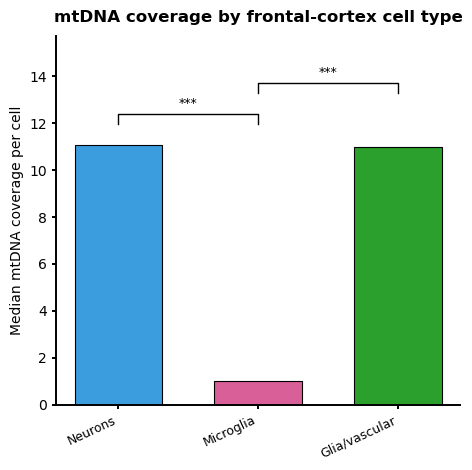

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = data.obs[["cell_type"]].copy()

df["mtDNA_depth"] = np.asarray(
    data.obsm["coverage_per_cell"]
).mean(axis=1)

df["cell_type"] = df["cell_type"].astype(str)
df = df.dropna(subset=["cell_type", "mtDNA_depth"])

order = ["Neurons", "Microglia", "Glia/vascular"]
df = df[df["cell_type"].isin(order)].copy()

summary = df.groupby("cell_type")["mtDNA_depth"].median().reindex(order)

pairs = [
    ("Neurons", "Microglia"),
    ("Neurons", "Glia/vascular"),
    ("Microglia", "Glia/vascular"),
]

sig_pairs = []

for g1, g2 in pairs:
    a = df.loc[df["cell_type"] == g1, "mtDNA_depth"]
    b = df.loc[df["cell_type"] == g2, "mtDNA_depth"]

    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")

    if p < 0.05:
        sig_pairs.append((g1, g2, p))

fig, ax = plt.subplots(figsize=(4.8, 4.8))

colors = ["#3b9ddd", "#d95f99", "#2ca02c"]
x = [0.00, 0.16, 0.32]
x_map = dict(zip(order, x))

ax.bar(
    x,
    summary.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.10
)

ax.set_xticks(
    x,
    ["Neurons", "Microglia", "Glia/vascular"],
    rotation=25,
    ha="right"
)

ax.set_ylabel("Median mtDNA coverage per cell")
ax.set_xlabel("")
ax.set_title("mtDNA coverage by frontal-cortex cell type", fontweight="bold", pad=10)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="y", length=3, width=1.4)
ax.tick_params(axis="x", length=3, width=1.4, labelsize=9)

base_top = summary.max()
step = base_top * 0.12
h = base_top * 0.04
start = base_top * 1.08

ax.set_ylim(0, start + step * max(1, len(sig_pairs)) + base_top * 0.10)

for i, (g1, g2, p) in enumerate(sig_pairs):
    x1 = x_map[g1]
    x2 = x_map[g2]
    y = start + i * step

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1)

    if p < 0.001:
        label = "***"
    elif p < 0.01:
        label = "**"
    else:
        label = "*"

    ax.text(
        (x1 + x2) / 2,
        y + h + base_top * 0.015,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()